In [7]:
import os, sys, importlib, pathlib
from pathlib import Path
import pandas as pd
import geopandas as gpd
sys.path.append(os.path.abspath(".."))
import matplotlib.pyplot as plt

# my utils
from utils import geoplot
OUTPUT_FOLDER_MAP=Path("../output_map1/changed_host")


In [2]:
gdf_joined=gpd.read_file("../data_geo\Q1Q2Q3\listings_paris2406_geo.gpkg")
# display(df_joined.head())
print(len(gdf_joined))
print(gdf_joined.status.value_counts())
print(gdf_joined.booking_rate_l90d.describe(include='all'))

62738
status
old_host         39919
reopen_host      11665
reactive_host     8999
new_host          2155
Name: count, dtype: int64
count    62738.000000
mean         0.076108
std          0.160898
min          0.000000
25%          0.000000
50%          0.014286
75%          0.077922
max          1.000000
Name: booking_rate_l90d, dtype: float64


[input] CIRCLE (COUNT) vmin vmax :None-None
vmin vmax of current groups: 0.3772290809327846 0.5059837242699856
[INFO] cbar takes bounds: quantile!
suitable k : 1.5403573629081948!


d:\Edu\Multilevel_Geovisualisaiton_Airbnb_JO\utils\geoplot.py:1155: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_merged.geometry.centroid


✅ [SAVE] map saved to ..\output_map1\changed_host\map_changed_host.jpg!


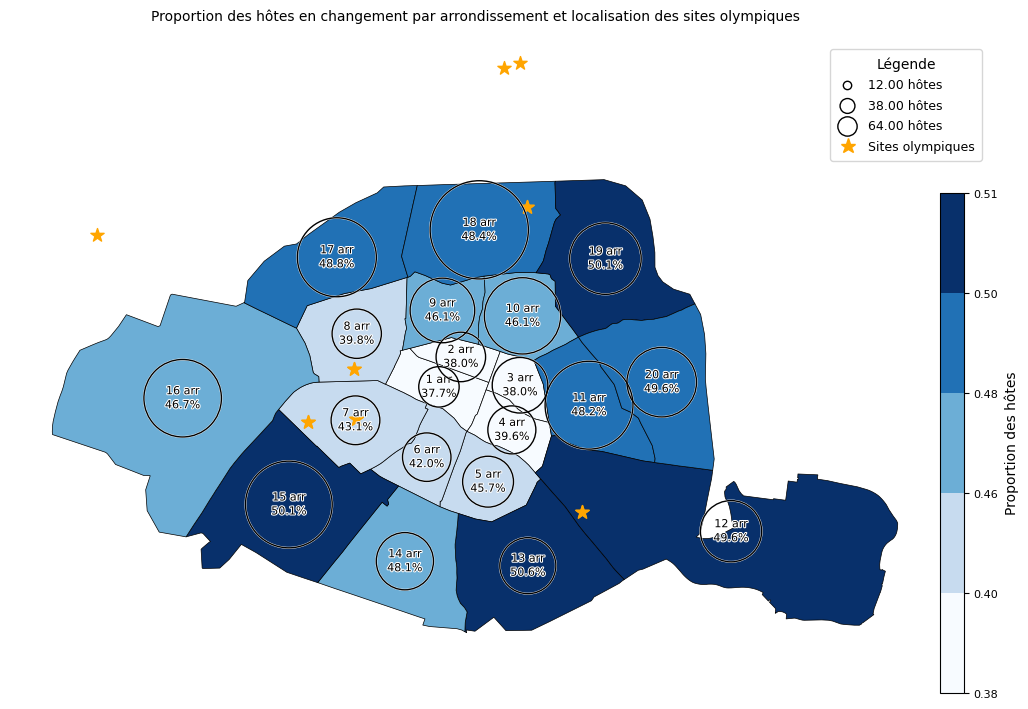

<module 'matplotlib.pyplot' from 'd:\\miniconda3\\envs\\geo_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [8]:
importlib.reload(geoplot)
from utils.geoplot import get_choro_circle_map
gdf_map=gpd.read_file("../data_map\paris_ar.gpkg")
gdf_venues=gpd.read_file("../data_geo\main_venues_JO.gpkg")

groups = (
    gdf_joined
    .groupby("c_ar", as_index=False)
    .agg(
        total_hosts=("is_changed", "count"),
        is_changed_count=('is_changed','sum'),
        is_changed_ratio=('is_changed','mean'),
    )
    .reset_index()
)

# display(groups)

get_choro_circle_map(groups=groups, 
            gdf_map=gdf_map, gdf_venues=gdf_venues,add_buffer_m=None, 
            col_choropleth="is_changed_ratio", col_circle="is_changed_count", groupby="c_ar",
            vmin_choro=None, vmax_choro=None, scheme='quantile', k_quantile=5, bins=None,
            vmin_circle=None, vmax_circle=None, 
            color_circle="black", color_star="orange", color_text="black",
            fig=None, subax=None,
            k=None, cmap="Blues",
            cbar_label="Proportion des hôtes",
            title="Proportion des hôtes en changement par arrondissement et localisation des sites olympiques",
            save=True, output_folder=OUTPUT_FOLDER_MAP, filename="map_changed_host.jpg"
        )
    

,index,c_ar,total_hosts,is_changed_count,is_changed_ratio
0,0,1.0,550,334,0.607273
1,1,2.0,825,550,0.666667
2,2,3.0,1040,718,0.690385
3,3,4.0,776,573,0.738402
4,4,5.0,871,667,0.765786
5,5,6.0,791,537,0.678887
6,6,7.0,800,580,0.725000
7,7,8.0,818,490,0.599022
8,8,9.0,1405,1060,0.754448
9,9,10.0,1957,1596,0.815534


[input] CIRCLE (COUNT) vmin vmax :None-None
vmin vmax of current groups: 0.5990220048899756 0.8762347472399767
[INFO] cbar takes bounds: quantile!
suitable k : 1.822821728034998!


d:\Edu\Multilevel_Geovisualisaiton_Airbnb_JO\utils\geoplot.py:1155: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_merged.geometry.centroid


✅ [SAVE] map saved to ..\output_map1\changed_host\map_status_changed_host.jpg!


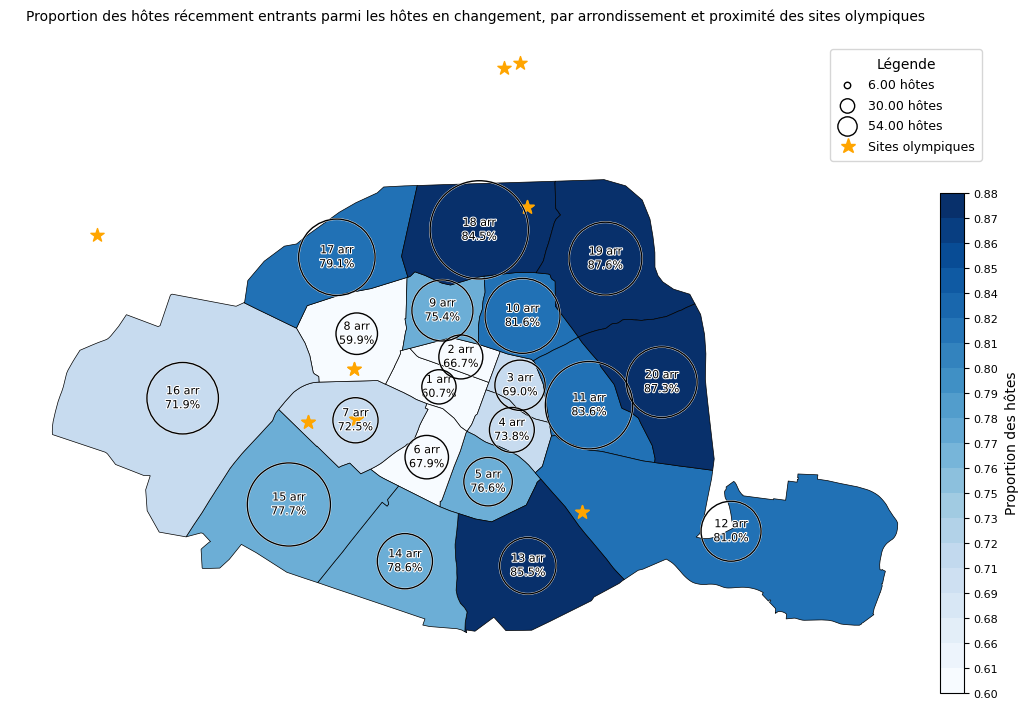

<module 'matplotlib.pyplot' from 'd:\\miniconda3\\envs\\geo_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [9]:
importlib.reload(geoplot)
from utils.geoplot import get_choro_circle_map

gdf_joined_changed=gdf_joined[gdf_joined['is_changed']==1]#filter

groups = (
    gdf_joined_changed
    .groupby("c_ar", as_index=False)
    .agg(
        total_hosts=("is_changed", "count"),
        is_changed_count=('status_changed','sum'),
        is_changed_ratio=('status_changed','mean'),
    )
    .reset_index()
)
display(groups)


get_choro_circle_map(groups=groups, 
            gdf_map=gdf_map, gdf_venues=gdf_venues,add_buffer_m=None, 
            col_choropleth="is_changed_ratio", col_circle="is_changed_count", groupby="c_ar",
            vmin_choro=None, vmax_choro=None, scheme='quantile', k_quantile=20, bins=None,
            vmin_circle=None, vmax_circle=None, 
            color_circle="black", color_star="orange", color_text="black",
            fig=None, subax=None,
            k=None, cmap="Blues",
            cbar_label="Proportion des hôtes",
            title="Proportion des hôtes récemment entrants parmi les hôtes en changement, par arrondissement et proximité des sites olympiques",
            save=True, output_folder=OUTPUT_FOLDER_MAP, filename="map_status_changed_host.jpg"

        )



,index,c_ar,total_hosts,is_changed_count,is_changed_ratio
0,0,1.0,550,216,0.392727
1,1,2.0,825,275,0.333333
2,2,3.0,1040,322,0.309615
3,3,4.0,776,203,0.261598
4,4,5.0,871,204,0.234214
5,5,6.0,791,254,0.321113
6,6,7.0,800,220,0.275000
7,7,8.0,818,328,0.400978
8,8,9.0,1405,345,0.245552
9,9,10.0,1957,361,0.184466


[input] CIRCLE (COUNT) vmin vmax :None-None
vmin vmax of current groups: 0.12376525276002324 0.40097799511002447
[INFO] cbar takes bounds: quantile!
suitable k : 8.80281690140845!


d:\Edu\Multilevel_Geovisualisaiton_Airbnb_JO\utils\geoplot.py:1155: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_merged.geometry.centroid


✅ [SAVE] map saved to ..\output_map1\changed_host\map_sp_changed_old_host.jpg!


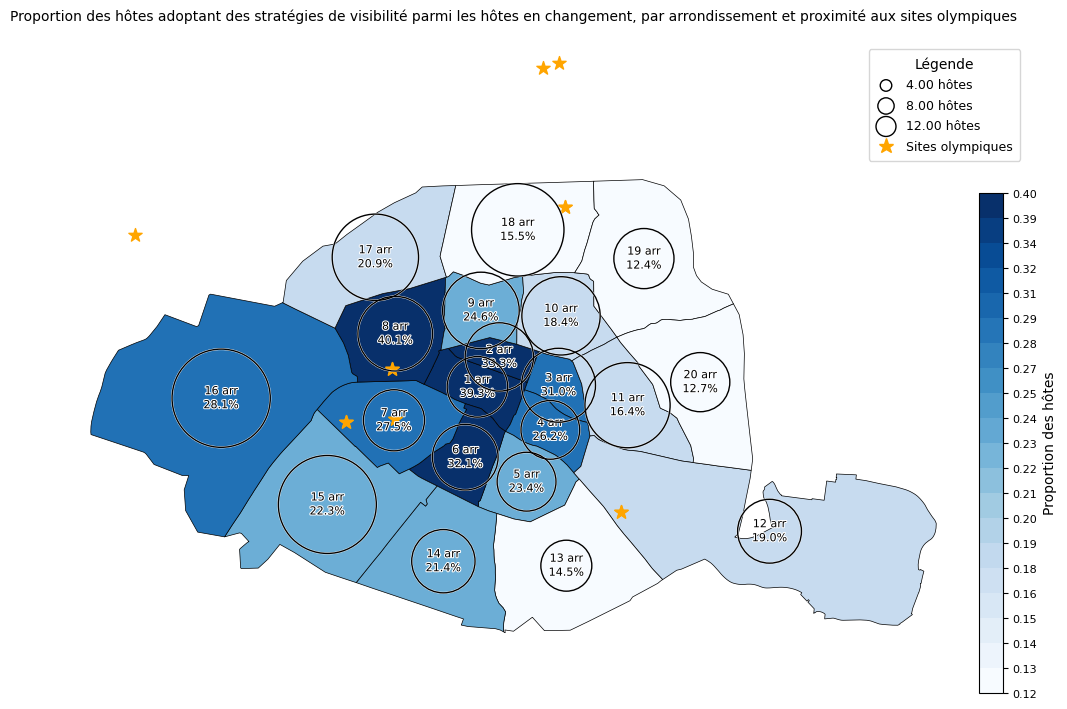

<module 'matplotlib.pyplot' from 'd:\\miniconda3\\envs\\geo_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [10]:
groups = (
    gdf_joined_changed
    .groupby("c_ar", as_index=False)
    .agg(
        total_hosts=("is_changed", "count"),
        is_changed_count=('old_host_sp_changed','sum'),
        is_changed_ratio=('old_host_sp_changed','mean'),
    )
    .reset_index()
)
display(groups)

get_choro_circle_map(groups=groups, 
            gdf_map=gdf_map, gdf_venues=gdf_venues,add_buffer_m=None, 
            col_choropleth="is_changed_ratio", col_circle="is_changed_count", groupby="c_ar",
            vmin_choro=None, vmax_choro=None, scheme='quantile', k_quantile=20, bins=None,
            vmin_circle=None, vmax_circle=None, 
            color_circle="black", color_star="orange", color_text="black",
            fig=None, subax=None,
            k=None, cmap="Blues",
            cbar_label="Proportion des hôtes",
            title="Proportion des hôtes adoptant des stratégies de visibilité parmi les hôtes en changement, par arrondissement et proximité aux sites olympiques",
            save=True, output_folder=OUTPUT_FOLDER_MAP, filename="map_sp_changed_old_host.jpg"
)